In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/raw/Bank_Churn.csv')
df.shape

(10000, 13)

In [11]:
df.dtypes #Check columns' types

CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [8]:
df.head() # 1st 5 sample rows of each column

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df.describe() #Return summary statistics

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [14]:
df.isnull().sum() #Check null

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [17]:
df['CustomerId'].duplicated().sum() #Count duplicated in Customer ID

np.int64(0)

In [18]:
df = df.drop(columns=['CustomerId','Surname']) # Drop 2 columns - not related to work on analysis

In [19]:
df.shape #Recheck shape after drop 2

(10000, 11)

In [20]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [21]:
df.info() #combine basic information, use this instead of dtypes

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [29]:
# Set up before ploting
sns.set_theme(style='whitegrid', palette='pastel')
FIG_DIR = '../outputs/figures'
os.makedirs(FIG_DIR, exist_ok=True)

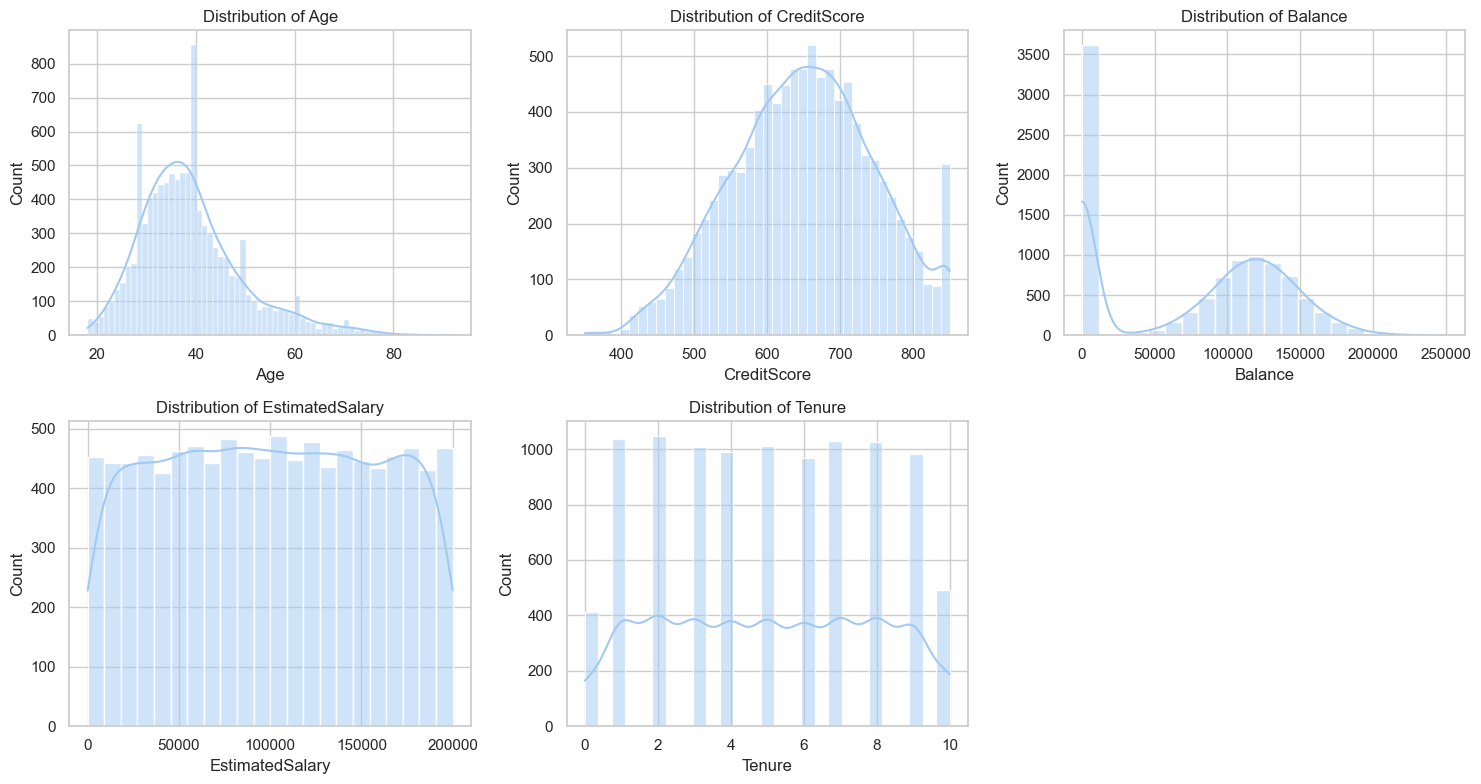

In [28]:
# Univariate analysis - Check the distribution of each variable/col
num_cols =['Age', 'CreditScore', 'Balance','EstimatedSalary', 'Tenure']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_univariate_numeric.png', dpi=120, bbox_inches='tight')
plt.show()
   

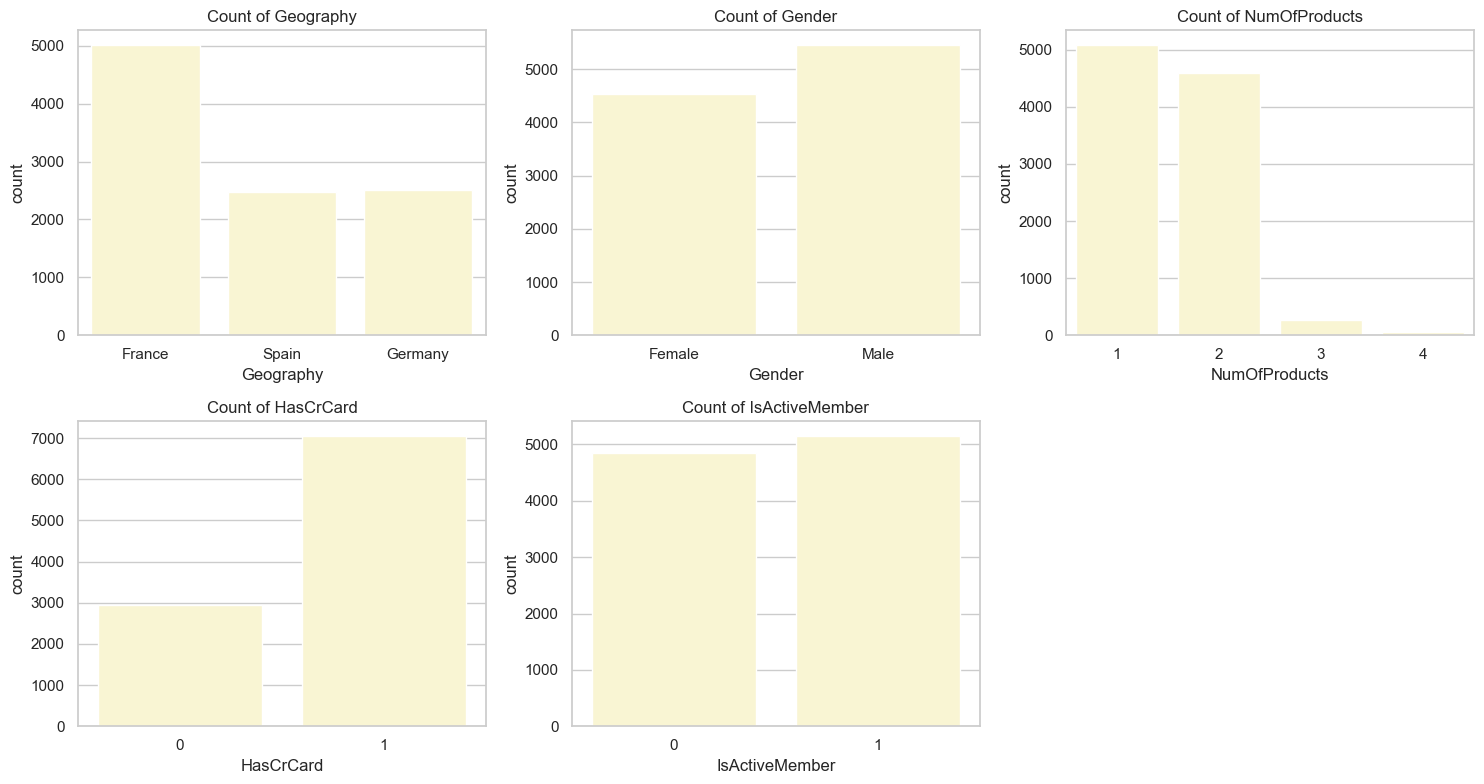

In [58]:
# Bar charts for categorical columns

cat_cols = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], color='lemonchiffon')
    axes[i].set_title(f'Count of {col}')
    
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_univariate_numeric.png', dpi=120, bbox_inches='tight')
plt.show()

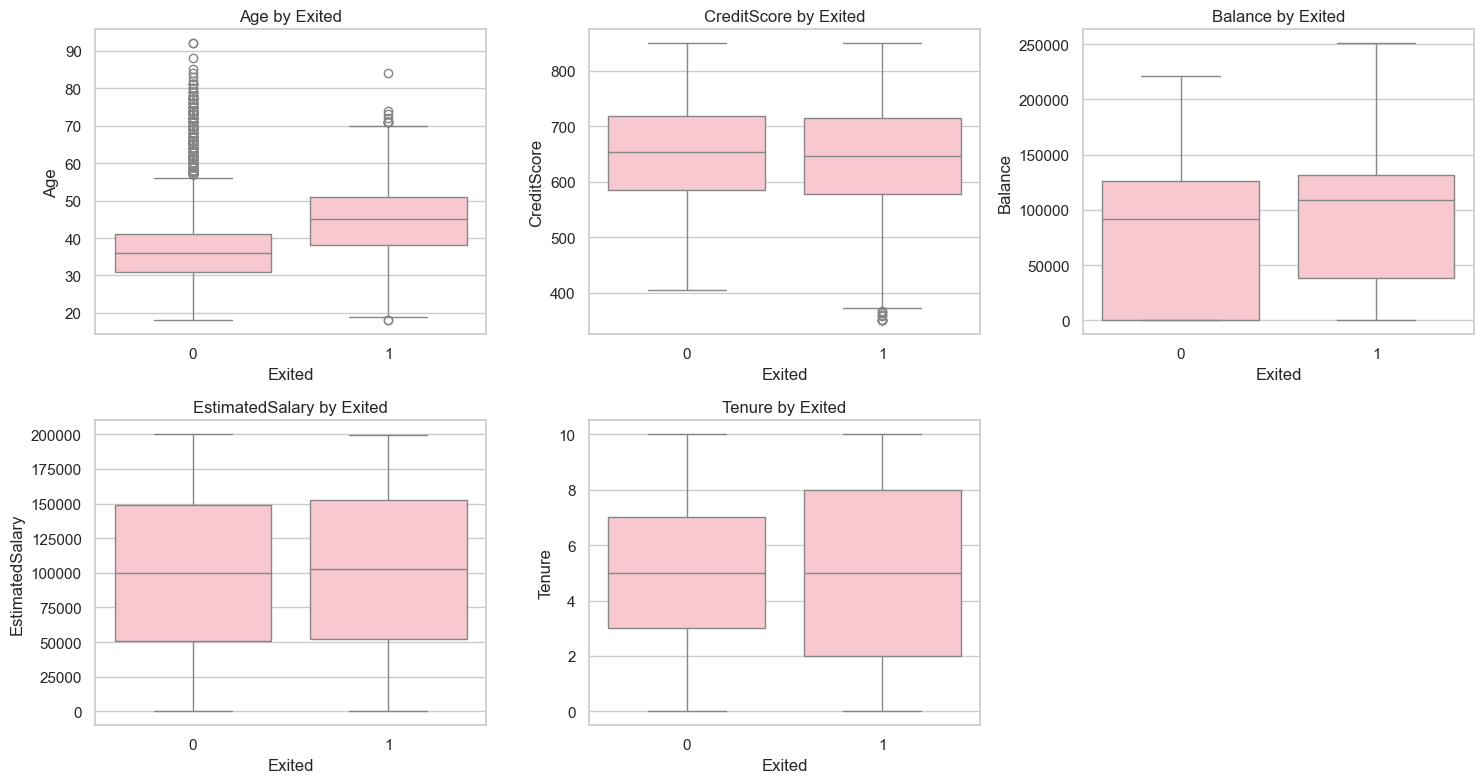

In [59]:
# Checking target relationship (between 'Exited' (churn) with 2 or more variables) - Boxplot
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate (num_cols):
    sns.boxplot(data=df, x='Exited', y=col, ax=axes[i], color='pink')
    axes[i].set_title(f'{col} by Exited')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_numeric_vs_exited_box.png', dpi=120, bbox_inches='tight')
plt.show()


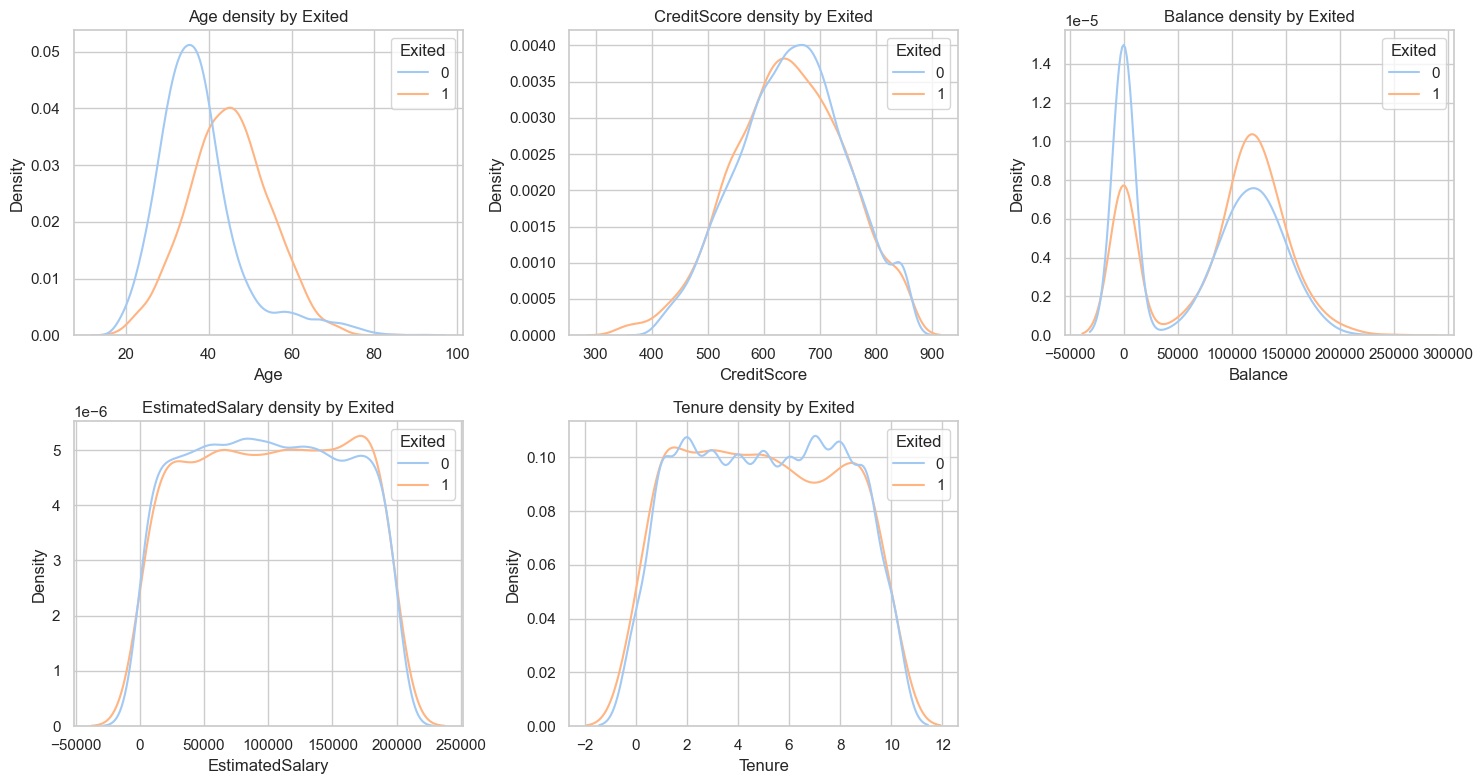

In [36]:
# Checking target relationship (between 'Exited' (churn) with 2 or more variables) - Boxplot
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes=axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Exited', common_norm=False, ax=axes[i])
    axes[i].set_title(f'{col} density by Exited')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_numeric_vs_exited_kde.png', dpi=120, bbox_inches='tight')
plt.show()

In [43]:
#Churn rate per category

def churn_rate(col):
    rate=df.groupby(col)['Exited'].mean().sort_values(ascending=False)
    print(f'\n Churn Rate by {col}')
    print(rate.round(3))
    return rate


 Churn Rate by Geography
Geography
Germany    0.324
Spain      0.167
France     0.162
Name: Exited, dtype: float64

 Churn Rate by Gender
Gender
Female    0.251
Male      0.165
Name: Exited, dtype: float64

 Churn Rate by IsActiveMember
IsActiveMember
0    0.269
1    0.143
Name: Exited, dtype: float64

 Churn Rate by HasCrCard
HasCrCard
0    0.208
1    0.202
Name: Exited, dtype: float64

 Churn Rate by NumOfProducts
NumOfProducts
4    1.000
3    0.827
1    0.277
2    0.076
Name: Exited, dtype: float64


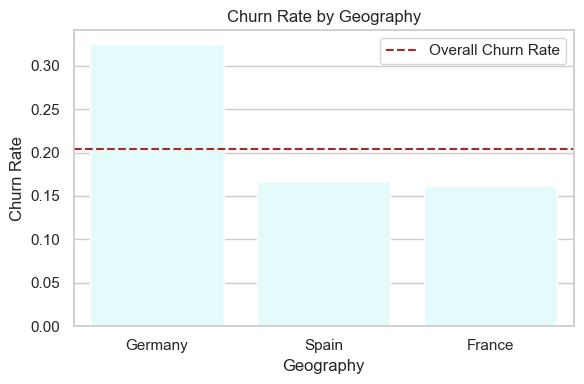

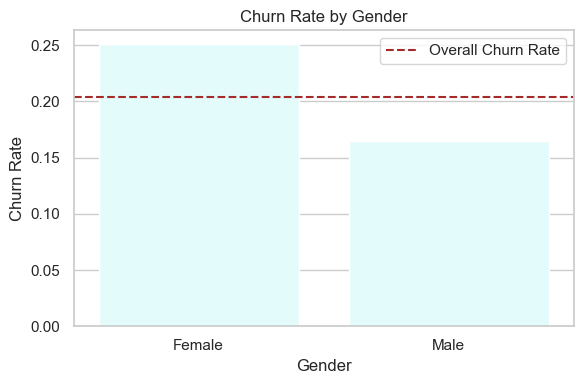

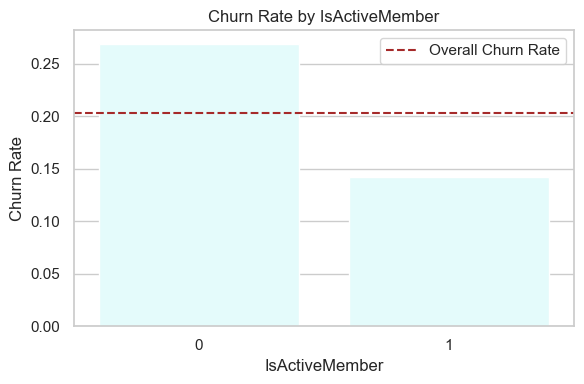

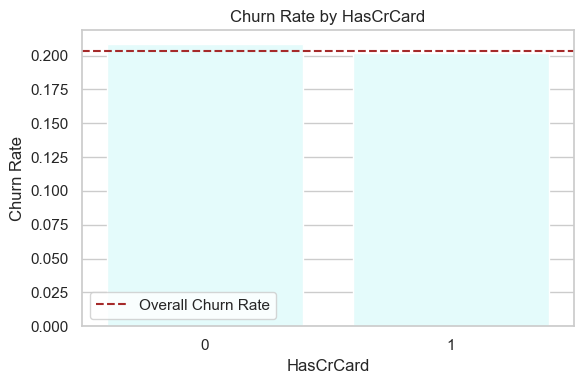

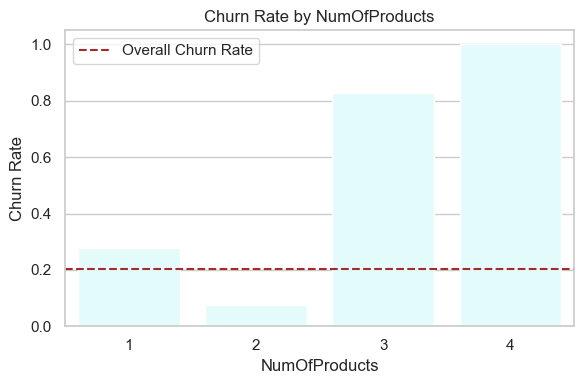

In [56]:
# Plot for each category
for col in ['Geography', 'Gender', 'IsActiveMember', 'HasCrCard','NumOfProducts']:
    rate = churn_rate(col)
    plt.figure(figsize=(6,4))
    sns.barplot(x=rate.index, y=rate.values, color='lightcyan')
    plt.axhline(df['Exited'].mean(), color='brown', linestyle='--', label='Overall Churn Rate')
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')
    plt.legend()
    plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_churn_by_{col}.png',dpi=120, bbox_inches='tight')
plt.show()


 Churn Rate by AgeBand
AgeBand
45-60    0.494
61+      0.279
30-45    0.144
18-30    0.076
Name: Exited, dtype: float64


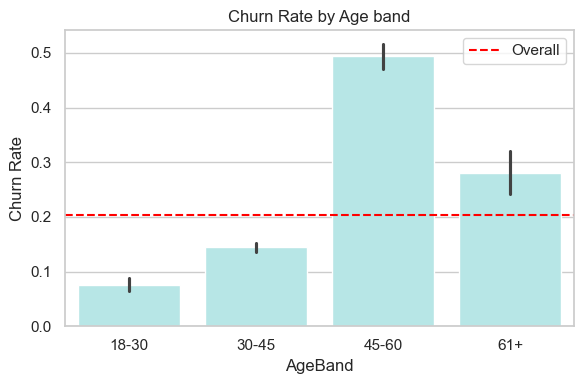

In [50]:
# Age is numeric, but binning makes it work for business insight

df['AgeBand'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '30-45', '45-60', '61+'],
    right=False,)
churn_rate('AgeBand')

plt.figure(figsize=(6,4))
sns.barplot(data=df, x='AgeBand', y='Exited', estimator='mean', color='paleturquoise')
plt.axhline(df['Exited'].mean(), color='red', linestyle='--', label='Overall')
plt.title('Churn Rate by Age band')
plt.ylabel('Churn Rate')
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_churn_by_AgeBand.png', dpi=120, bbox_inches='tight')
plt.show()


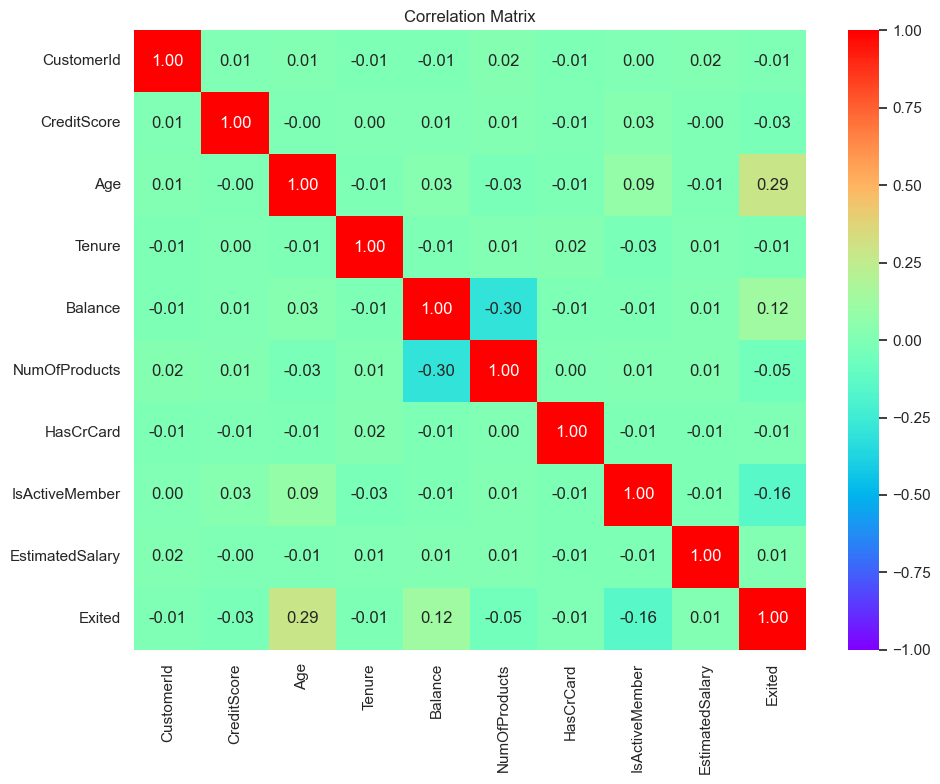

In [53]:
# Check correlation

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='rainbow',
            center=0,
            vmin=-1, vmax=1,)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_correlation_heatmap.png', dpi=120, bbox_inches='tight')            
plt.show()

In [ ]:
# Checkpoints
# - Age is the strongest driver with the highest positive correlation with churn. Moreover, churn rate climbs from ~7% (18-30) to over 50% (45-60+). Age is a matter.
# - Germany churn at 32%, double to France and Spain. The regional issue is worth investigating.
# - Number of Products is somehow related, with more than 3 products, 100% churn - could be likely a product or onboarding problem.
# - Inactive members have a ~27% churn rate, twice as active ones. Making activation actionable retention lever in this case.
# - Other columns are essentially uncorrelated with churn.